# Document Field Extraction using LayoutLM (Visual Question Answering)

Extracts structured fields from document images using **visual question answering**.

## Architecture Flow

```mermaid
flowchart TB
    subgraph INPUT["📄 Input"]
        IMG["Image File<br/>(JPG/PNG/BMP)"]
        PDF["PDF Document"]
    end

    subgraph PDFDETECT["🔍 Smart PDF Detection"]
        CHECK{"is_native_pdf()?<br/>text > 50 chars?"}
        NATIVE["Native PDF<br/>(Word → PDF, forms)"]
        SCANNED["Scanned PDF<br/>(image as PDF)"]
    end

    subgraph PREPROCESSING["🔧 Preprocessing (affects Tesseract only)"]
        LOAD["load_image()"]
        PYMUPDF_NATIVE["PyMuPDF<br/>150 DPI<br/>(no preprocessing)"]
        PYMUPDF_SCANNED["PyMuPDF<br/>300 DPI"]
        RGB["Convert to RGB<br/>PIL Image"]
        
        subgraph PIPELINES["preprocess_for_ocr()"]
            LIGHT["<b>Light Pipeline</b><br/>• Contrast +20%<br/>• Sharpen<br/>• Resize ≥1000px"]
            FULL["<b>Full Pipeline</b><br/>• Grayscale<br/>• 2× Resize + CLAHE<br/>• Conditional Denoise<br/>• Deskew"]
        end
    end

    subgraph LAYOUTLM["🤖 LayoutLM Pipeline"]
        direction TB
        subgraph OCR["Tesseract OCR<br/>(automatic)"]
            TEXT["Extract Text"]
            BBOX["Extract Bounding Boxes"]
        end
        MODEL["impira/layoutlm-document-qa<br/>Document Understanding Transformer<br/><i>(receives text+bbox only, NOT pixels)</i>"]
    end

    subgraph QA["❓ Question Answering"]
        Q1["What is the patient's name?"]
        Q2["What is the doctor's name?"]
        Q3["What is the clinic name?"]
        Q4["What is the certificate ID?"]
        Q5["What is the issue date?"]
    end

    subgraph OUTPUT["📊 Output"]
        FIELDS["Structured Fields<br/>+ Confidence Scores"]
        DF["Pandas DataFrame"]
    end

    IMG --> LOAD --> RGB
    RGB --> LIGHT
    RGB --> FULL
    LIGHT --> OCR
    FULL --> OCR
    PDF --> CHECK
    CHECK -->|"Yes (has text)"| NATIVE --> PYMUPDF_NATIVE --> OCR
    CHECK -->|"No (image only)"| SCANNED --> PYMUPDF_SCANNED --> RGB
    TEXT --> MODEL
    BBOX --> MODEL
    MODEL --> Q1 & Q2 & Q3 & Q4 & Q5
    Q1 & Q2 & Q3 & Q4 & Q5 --> FIELDS
    FIELDS --> DF

    style INPUT fill:#e1f5fe
    style PDFDETECT fill:#fff9c4
    style PREPROCESSING fill:#fff3e0
    style PIPELINES fill:#ffe0b2
    style LAYOUTLM fill:#f3e5f5
    style QA fill:#e8f5e9
    style OUTPUT fill:#fce4ec
    style LIGHT fill:#c8e6c9
    style FULL fill:#ffccbc
```

## Pipeline Summary

| Stage | Component | Description |
|-------|-----------|-------------|
| **1. Input** | `load_image()` | Accepts JPG, PNG, BMP, PDF |
| **2. PDF Detection** | `is_native_pdf()` | Checks if PDF has text layer (>50 chars) |
| **3a. Native PDF** | PyMuPDF | Renders at **150 DPI**, skips preprocessing (text already crisp) |
| **3b. Scanned PDF** | PyMuPDF | Renders at **300 DPI** + selected preprocessing pipeline |
| **3c. Images** | `preprocess_for_ocr()` | Applies light or full preprocessing based on `PREPROCESSING_MODE` |
| **4. OCR** | Tesseract | Extracts text + bounding boxes (automatic via HF pipeline) |
| **5. Model** | `impira/layoutlm-document-qa` | Document understanding transformer (~500 MB) |
| **6. QA** | Multi-question strategy | Asks multiple question variants per field |
| **7. Output** | Structured dict | Field values + confidence scores |

### Two Preprocessing Pipelines

| Pipeline | Mode | Best For | Techniques |
|----------|------|----------|------------|
| **Light** | `"light"` | Clean documents, digital PDFs | Contrast +20%, sharpen, resize ≥1000px |
| **Full** | `"full"` | Scanned/faded/noisy documents | Grayscale → 2× CLAHE → conditional denoise → deskew |

> **Key insight:** LayoutLM v1 is NOT a vision model — it only receives **text + bounding boxes** from Tesseract OCR. Preprocessing affects OCR quality, not the model directly.

### Smart PDF Handling

| PDF Type | Detection | DPI | Preprocessing | Why |
|----------|-----------|-----|---------------|-----|
| **Native** | `get_text()` > 50 chars | 150 | ❌ Skip | Text is vector-based, always crisp |
| **Scanned** | `get_text()` ≤ 50 chars | 300 | ✅ Selected pipeline | Image needs enhancement for OCR |

### Model: `impira/layoutlm-document-qa`

| Feature | Value |
|---|---|
| Architecture | LayoutLM (Document understanding transformer) |
| Task | Extractive QA over document images |
| Input | Image + natural language question |
| Output | Answer text + confidence score |
| Size | ~500 MB |

**Key difference from OCR + NER approach:**
- **OCR + NER**: Image → Tesseract text → NER model → entity extraction → post-processing
- **LayoutLM QA**: Image → ask question → get answer directly (end-to-end visual understanding)

**Prerequisites:**
- `pip install transformers torch pillow` (LayoutLM pipeline — downloads ~500 MB on first run)
- `pip install pymupdf` (for PDF support)
- `pip install opencv-python` (for full preprocessing pipeline)
- `brew install tesseract` (required by the HF pipeline internally)

## Step 0 — Environment Setup

Adds the notebook's parent folder to Python's import path so project modules
can be imported without installing the package.

### Tesseract OCR Requirement

**IMPORTANT:** The `impira/layoutlm-document-qa` model requires **Tesseract OCR** to be
installed. LayoutLM is a multimodal model that needs OCR text + bounding boxes as input —
the Hugging Face pipeline extracts these automatically using Tesseract.

**Install Tesseract:**
```bash
# macOS
brew install tesseract

# Ubuntu/Debian
sudo apt-get install tesseract-ocr

# Windows
# Download installer from: https://github.com/UB-Mannheim/tesseract/wiki
```

The code cell below adds `/opt/homebrew/bin` (Homebrew's default location on Apple Silicon)
to `$PATH` so the pipeline can find Tesseract.

In [1]:
# Make the project root importable.
import os
import sys
from pathlib import Path

# ── Fix Tesseract PATH ─────────────────────────────────────────────────────────
# The LayoutLM pipeline uses pytesseract internally, which looks for the
# `tesseract` binary in $PATH. On macOS with Homebrew, it's at /opt/homebrew/bin.
# Adding this to PATH before importing transformers ensures the pipeline finds it.
TESSERACT_PATH = "/opt/homebrew/bin"
if TESSERACT_PATH not in os.environ.get("PATH", ""):
    os.environ["PATH"] = TESSERACT_PATH + ":" + os.environ.get("PATH", "")
    print(f"Added {TESSERACT_PATH} to PATH for Tesseract OCR")

# Verify Tesseract is now accessible.
import shutil
tesseract_bin = shutil.which("tesseract")
if tesseract_bin:
    print(f"Tesseract found: {tesseract_bin}")
else:
    print("WARNING: Tesseract not found! Install with: brew install tesseract")
# ───────────────────────────────────────────────────────────────────────────────

# Notebook lives in <root>/Hugging face model/impira ---- layoutlm-document-qa/,
# so we go up two levels to reach the workspace root.
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Tesseract found: /opt/homebrew/bin/tesseract
Project root: /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing


## Configuration & Image Discovery

Defines **which images the notebook will process** and **which one to inspect**
in the single-image cells below.

| Variable | Meaning |
|---|---|
| `IMAGE_FOLDER` | Folder scanned for input images |
| `INSPECT_INDEX` | Index into the sorted file list — controls single-image inspection |
| `EXTENSIONS`   | File suffixes accepted (case-insensitive) |

The cell enumerates the folder, filters by extension, sorts the results, and
prints the list with an arrow marker (`← inspect`) next to whichever file will
be used for single-image inspection.

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Root folder scanned recursively — every image/PDF in any subfolder is picked up.
IMAGE_FOLDER = Path.cwd().parent.parent / "test_data" / "sick_notes"

# Which image to use for the single-image inspection cells below.
INSPECT_INDEX = 22

# Supported extensions.
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".pdf"}
# ───────────────────────────────────────────────────────────────────────────────

if not IMAGE_FOLDER.exists():
    raise FileNotFoundError(f"Folder not found: {IMAGE_FOLDER}")

image_paths = sorted(
    p for p in IMAGE_FOLDER.rglob("*")
    if p.is_file() and p.suffix.lower() in EXTENSIONS
)

if not image_paths:
    raise FileNotFoundError(f"No images found under {IMAGE_FOLDER}")

print(f"Found {len(image_paths)} file(s) under {IMAGE_FOLDER}:")
for i, p in enumerate(image_paths):
    marker = " ← inspect" if i == INSPECT_INDEX else ""
    rel = p.relative_to(IMAGE_FOLDER)
    print(f"  [{i}] {rel}{marker}")

Found 23 file(s) under /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing/test_data/sick_notes:
  [0] Test data/Sick_Note_1.jpg
  [1] Test data/Sick_note_2.jpg
  [2] Test data/Sick_note_8.pdf
  [3] Test data/sick_note_10.jpg
  [4] Test data/sick_note_12.pdf
  [5] Test data/sick_note_13.jpg
  [6] Test data/sick_note_14.pdf
  [7] Test data/sick_note_15.jpg
  [8] Test data/sick_note_17.pdf
  [9] Test data/sick_note_18.pdf
  [10] Test data/sick_note_19.png
  [11] Test data/sick_note_20.pdf
  [12] Test data/sick_note_21.pdf
  [13] Test data/sick_note_3.jpg
  [14] Test data/sick_note_9.jpg
  [15] authentic/SickNote_AI_jpg1.jpg
  [16] fake/AI_c2pa_image_2.png
  [17] suspicious/Sick_Note_1.jpg
  [18] suspicious/Sick_note_No_Seal.png
  [19] suspicious/date_mismatch.png
  [20] suspicious/negative_no_seal_001.png
  [21] suspicious/sicknote_1.jpg
  [22] suspicious/sicknote_1.png ← inspect


## Step 1 — Helper Functions

### Two Preprocessing Pipelines

Since **LayoutLM v1** only receives OCR text + bounding boxes (not image pixels), preprocessing
only affects **Tesseract OCR quality**. We provide two pipelines:

| Pipeline | Mode | Best For | Techniques |
|----------|------|----------|------------|
| **Light** | `"light"` | Clean documents, digital PDFs | Contrast +20%, sharpen, resize |
| **Full** | `"full"` | Scanned/faded/noisy documents | Grayscale, CLAHE, denoise, deskew |

### Pipeline Comparison

```
Light Pipeline (fast, preserves colors):
  Image → Contrast +20% → Sharpen → Resize ≥1000px → Tesseract

Full OCR Pipeline (aggressive, grayscale output):
  Image → Grayscale → 2× Resize + CLAHE → Conditional Denoise → Deskew → Tesseract
```

### Smart PDF Detection

`is_native_pdf(pdf_path)` checks if a PDF has an embedded text layer:

| PDF Type | Has Text Layer | Example | Processing Strategy |
|----------|----------------|---------|---------------------|
| **Native PDF** | ✅ Yes | Word → PDF, digital forms | Lower DPI (150), no preprocessing |
| **Scanned PDF** | ❌ No | Image saved as PDF | Higher DPI (300), full preprocessing |

### Configuration

Set `PREPROCESSING_MODE` in the config cell to switch between pipelines:
- `"light"` — faster, good for clean documents (default)
- `"full"` — aggressive OCR optimization for poor quality scans
- `"none"` — no preprocessing (for debugging/comparison)

In [4]:
import fitz  # PyMuPDF
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter

# ═══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING MODE — Choose which pipeline to use
# ═══════════════════════════════════════════════════════════════════════════════
# Options:
#   "light" — fast, preserves colors (contrast +20%, sharpen, resize)
#   "full"  — aggressive OCR optimization (grayscale, CLAHE, denoise, deskew)
#   "none"  — no preprocessing (for debugging/comparison)
PREPROCESSING_MODE = "light"


# ── Smart PDF Detection ────────────────────────────────────────────────────────
def is_native_pdf(pdf_path: Path) -> bool:
    """Check if a PDF has an embedded text layer (native PDF vs scanned image).
    
    Native PDFs (Word → PDF, digital forms) have extractable text.
    Scanned PDFs (image saved as PDF) have little or no extractable text.
    
    Returns:
        True if PDF has significant text content (native PDF)
        False if PDF appears to be a scanned image
    """
    try:
        doc = fitz.open(str(pdf_path))
        page = doc[0]
        text = page.get_text().strip()
        doc.close()
        
        # If we can extract more than 50 characters, it's likely a native PDF
        return len(text) > 50
    except Exception:
        return False


def get_pdf_text_with_boxes(pdf_path: Path, page_index: int = 0) -> dict:
    """Extract text and bounding boxes from a native PDF."""
    doc = fitz.open(str(pdf_path))
    page = doc[page_index]
    
    full_text = page.get_text()
    words = []
    for word_info in page.get_text("words"):
        x0, y0, x1, y1, word, block_no, line_no, word_no = word_info
        words.append({"text": word, "bbox": (x0, y0, x1, y1)})
    
    doc.close()
    return {"text": full_text, "words": words}


# ═══════════════════════════════════════════════════════════════════════════════
# PIPELINE 1: LIGHT PREPROCESSING (RGB preserved)
# ═══════════════════════════════════════════════════════════════════════════════
def preprocess_light(img: Image.Image, target_width: int = 1000) -> Image.Image:
    """Light preprocessing — keeps RGB, good for clean documents.
    
    Steps:
    1. Contrast boost (+20%) — makes text stand out
    2. Sharpen — sharpens text edges
    3. Resize — upscale small images (Tesseract needs ≥1000px width)
    
    Args:
        img: PIL Image in RGB mode
        target_width: Minimum width to resize to (default 1000px)
    
    Returns:
        Preprocessed PIL Image (RGB)
    """
    # 1. Boost contrast by 20%
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(1.2)
    
    # 2. Sharpen text edges
    img = img.filter(ImageFilter.SHARPEN)
    
    # 3. Upscale if too small
    if img.width < target_width:
        ratio = target_width / img.width
        new_size = (target_width, int(img.height * ratio))
        img = img.resize(new_size, Image.LANCZOS)
    
    return img


# ═══════════════════════════════════════════════════════════════════════════════
# PIPELINE 2: FULL OCR PREPROCESSING (Grayscale, CLAHE, Denoise, Deskew)
# ═══════════════════════════════════════════════════════════════════════════════
def _estimate_noise_level(gray_img: np.ndarray) -> float:
    """Estimate noise level using Laplacian variance."""
    laplacian = cv2.Laplacian(gray_img, cv2.CV_64F)
    return laplacian.var()


def _deskew_image(gray_img: np.ndarray) -> np.ndarray:
    """Deskew a grayscale image using Hough line transform."""
    # Detect edges
    edges = cv2.Canny(gray_img, 50, 150, apertureSize=3)
    
    # Detect lines
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100,
                            minLineLength=100, maxLineGap=10)
    
    if lines is None or len(lines) == 0:
        return gray_img  # No lines detected, return original
    
    # Calculate angles
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 - x1 != 0:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            # Only consider near-horizontal lines
            if abs(angle) < 45:
                angles.append(angle)
    
    if not angles:
        return gray_img
    
    # Median angle
    median_angle = np.median(angles)
    
    # Skip if angle is negligible
    if abs(median_angle) < 0.5:
        return gray_img
    
    # Rotate to deskew
    h, w = gray_img.shape
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, median_angle, 1.0)
    deskewed = cv2.warpAffine(gray_img, rotation_matrix, (w, h),
                               flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REPLICATE)
    
    return deskewed


def preprocess_full(img: Image.Image, 
                    scale: int = 2,
                    clahe_clip: float = 2.0,
                    clahe_grid: tuple = (8, 8),
                    denoise_threshold: float = 500.0,
                    denoise_strength: int = 8,
                    do_deskew: bool = True) -> Image.Image:
    """Full OCR preprocessing — aggressive optimization for poor quality scans.
    
    Steps:
    1. Convert to grayscale
    2. 2× resize + CLAHE contrast enhancement
    3. Conditional denoising (if noise level > threshold)
    4. Deskew (straighten tilted text)
    
    Args:
        img: PIL Image in RGB mode
        scale: Resize scale factor (default 2×)
        clahe_clip: CLAHE clip limit (default 2.0)
        clahe_grid: CLAHE tile grid size (default 8×8)
        denoise_threshold: Noise threshold for conditional denoising
        denoise_strength: Denoising strength (h parameter)
        do_deskew: Whether to apply deskewing
    
    Returns:
        Preprocessed PIL Image (grayscale, converted back to RGB for pipeline compatibility)
    """
    # Convert PIL to OpenCV (RGB → BGR → Grayscale)
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    
    # 1. 2× Resize + CLAHE
    h, w = gray.shape
    gray_scaled = cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)
    gray_clahe = clahe.apply(gray_scaled)
    
    # 2. Conditional denoising
    noise_level = _estimate_noise_level(gray_clahe)
    if noise_level > denoise_threshold:
        gray_denoised = cv2.fastNlMeansDenoising(
            gray_clahe,
            h=denoise_strength,
            templateWindowSize=7,
            searchWindowSize=21,
        )
        print(f"    [Denoised: noise={noise_level:.1f} > {denoise_threshold}]")
    else:
        gray_denoised = gray_clahe
        print(f"    [Denoise skipped: noise={noise_level:.1f} ≤ {denoise_threshold}]")
    
    # 3. Deskew
    if do_deskew:
        gray_final = _deskew_image(gray_denoised)
    else:
        gray_final = gray_denoised
    
    # Convert back to PIL RGB (grayscale → 3-channel for pipeline compatibility)
    # Tesseract can handle grayscale, but the HF pipeline expects RGB
    rgb_array = cv2.cvtColor(gray_final, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(rgb_array)


# ═══════════════════════════════════════════════════════════════════════════════
# UNIFIED PREPROCESSING FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════
def preprocess_for_ocr(img: Image.Image, mode: str = None) -> Image.Image:
    """Apply preprocessing based on the selected mode.
    
    Args:
        img: PIL Image in RGB mode
        mode: Preprocessing mode ("light", "full", "none"). 
              If None, uses global PREPROCESSING_MODE.
    
    Returns:
        Preprocessed PIL Image
    """
    mode = mode or PREPROCESSING_MODE
    
    if mode == "none":
        return img
    elif mode == "full":
        return preprocess_full(img)
    else:  # "light" (default)
        return preprocess_light(img)


# ── PDF → Image Helper ─────────────────────────────────────────────────────────
def pdf_page_to_image(pdf_path: Path, page_index: int = 0, dpi: int = 300) -> Image.Image:
    """Render one PDF page to a PIL Image at the given DPI."""
    doc = fitz.open(str(pdf_path))
    page = doc[page_index]
    mat = fitz.Matrix(dpi / 72, dpi / 72)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    doc.close()
    return img


# ── Image Loading Helper ───────────────────────────────────────────────────────
def load_image(path: Path, preprocess: bool = True, mode: str = None) -> Image.Image:
    """Load an image from file — supports both raster images and PDFs.
    
    For PDFs, uses smart detection:
    - Native PDFs (with text layer): Lower DPI, no preprocessing
    - Scanned PDFs (image only): Higher DPI + preprocessing
    
    Args:
        path: Path to image or PDF file
        preprocess: If True, apply preprocessing (default True)
        mode: Preprocessing mode override ("light", "full", "none")
    
    Returns:
        PIL Image ready for the LayoutLM pipeline
    """
    mode = mode or PREPROCESSING_MODE
    
    if path.suffix.lower() == ".pdf":
        native = is_native_pdf(path)
        
        if native:
            print(f"  [Native PDF — 150 DPI, no preprocessing]")
            img = pdf_page_to_image(path, dpi=150)
            return img
        else:
            print(f"  [Scanned PDF — 300 DPI + {mode} preprocessing]")
            img = pdf_page_to_image(path, dpi=300)
            if preprocess:
                img = preprocess_for_ocr(img, mode=mode)
            return img
    else:
        img = Image.open(path)
        if img.mode != "RGB":
            img = img.convert("RGB")
        
        if preprocess:
            print(f"  [Image — {mode} preprocessing]")
            img = preprocess_for_ocr(img, mode=mode)
        
        return img


# ═══════════════════════════════════════════════════════════════════════════════
print(f"Helper functions loaded. PREPROCESSING_MODE = '{PREPROCESSING_MODE}'")
print()
print("Available pipelines:")
print("  • 'light' — Contrast +20%, sharpen, resize (fast, RGB preserved)")
print("  • 'full'  — Grayscale, 2× resize, CLAHE, denoise, deskew (aggressive)")
print("  • 'none'  — No preprocessing (for debugging)")
print()
print("To change: set PREPROCESSING_MODE = 'full' and re-run this cell.")

Helper functions loaded. PREPROCESSING_MODE = 'light'

Available pipelines:
  • 'light' — Contrast +20%, sharpen, resize (fast, RGB preserved)
  • 'full'  — Grayscale, 2× resize, CLAHE, denoise, deskew (aggressive)
  • 'none'  — No preprocessing (for debugging)

To change: set PREPROCESSING_MODE = 'full' and re-run this cell.


## Step 2 — LayoutLM Document QA Model Setup

Loads the `impira/layoutlm-document-qa` model once and reuses it for all images.

### Model Details

| Property | Value |
|---|---|
| Model ID | `impira/layoutlm-document-qa` |
| Pipeline type | `document-question-answering` |
| Input | PIL Image + question string |
| Output | `{"answer": str, "score": float, "start": int, "end": int}` |

### Lazy Singleton Pattern

The model is ~500 MB and takes 30–60 seconds to load. To avoid paying that
cost more than once per session, the pipeline is stored in a module-level
variable and returned on subsequent calls:

```python
_qa_pipeline: object = None  # cache slot

def _get_qa_pipeline() -> object:
    global _qa_pipeline
    if _qa_pipeline is None:  # first call → build
        _qa_pipeline = pipeline("document-question-answering", model=MODEL_ID)
    return _qa_pipeline       # subsequent calls → reuse
```

### Model Cache Location

On first call, the model is automatically downloaded and cached by Hugging Face:

- **macOS/Linux**: `~/.cache/huggingface/hub/`
- **Windows**: `C:\Users\<username>\.cache\huggingface\hub\`

In [5]:
from transformers import pipeline

# Model ID — LayoutLM fine-tuned for document question answering.
_MODEL_ID = "impira/layoutlm-document-qa"
_qa_pipeline: object = None  # lazy-loaded on first call


def _get_qa_pipeline() -> object:
    """Return the document QA pipeline, loading it on first call."""
    global _qa_pipeline
    if _qa_pipeline is None:
        print(f"Loading LayoutLM model ({_MODEL_ID}) — first call only, ~30–60 sec ...")
        _qa_pipeline = pipeline(
            "document-question-answering",
            model=_MODEL_ID,
        )
        print("LayoutLM model ready.")
    return _qa_pipeline


# Reset the pipeline to force reload with the new PATH.
_qa_pipeline = None
print(f"QA loader defined — model will reload on next extract_fields_qa() call.")

/Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


QA loader defined — model will reload on next extract_fields_qa() call.


## Step 3 — Field Extraction via Question Answering

The **core extractor**. Asks targeted questions about the document image and
collects the model's answers into a structured dictionary.

### Improvements Applied

| Improvement | Before | After | Impact |
|-------------|--------|-------|--------|
| **Confidence threshold** | 0.1 | **0.3** | Filters low-quality/hallucinated answers |
| **Question phrasing** | Generic | **Document-specific** | Better extraction accuracy |
| **Question variants** | 2-3 per field | **4-5 per field** | More chances to find the answer |
| **Ambiguity fix** | `'Name:'` (ambiguous) | `'Patient Name:'` (specific) | Prevents doctor↔patient confusion |

### Questions per Field

| Field | Question Variants |
|---|---|
| `patient_name` | "What is the patient's full name...?", "Who is the patient...?", "What name appears after **'Patient Name:'** or **'Patient:'**?", "Who is receiving medical treatment...?" |
| `doctor_name` | "What is the doctor's name who signed...?", "Who is the physician...?", "What name appears after 'Dr.' or 'Physician:' or 'Doctor:'?", "Who issued or signed...?" |
| `clinic_name` | "What is the clinic or hospital name on the letterhead?", "What is the name of the medical facility?", ... |
| `certificate_id` | "What is the certificate ID or document number?", "What number appears after 'Ref:', 'ID:', or 'No:'?", ... |
| `issue_date` | "What is the date this certificate was issued?", "When was this medical certificate signed?", ... |

### Output Format

```python
{
    "patient_name": "John Smith",
    "patient_name_confidence": 0.95,
    "doctor_name": "Dr. Anna Müller",
    "doctor_name_confidence": 0.88,
    ...
}
```

Each field includes a `_confidence` suffix with the model's score (0.0–1.0).

### Confidence Threshold

Answers with confidence below `MIN_CONFIDENCE` (**0.3**, raised from 0.1) are
discarded as unreliable — this filters most hallucinated answers when the
field isn't clearly present in the document.

### Avoiding Field Confusion

**Problem:** Generic questions like `"What name appears after 'Name:'?"` can match
either patient or doctor sections, causing the model to return the wrong name.

**Solution:** Use explicit field labels in questions:
- ❌ `"What name appears after 'Name:'?"` → ambiguous
- ✅ `"What name appears after 'Patient Name:' or 'Patient:'?"` → specific to patient
- ✅ `"What name appears after 'Dr.' or 'Physician:'?"` → specific to doctor

In [7]:
from typing import Any

# Minimum confidence threshold — raised from 0.1 to 0.3 to filter low-quality answers.
# The model sometimes hallucinates when uncertain; 0.3 filters most of this noise.
MIN_CONFIDENCE = 0.3

# Questions to ask for each field.
# Improved with document-specific phrasing for better extraction accuracy.
# IMPORTANT: Questions must be unambiguous — avoid generic terms like "Name:" that
# could match multiple fields (e.g., patient name vs doctor name).
_FIELD_QUESTIONS = {
    "patient_name": [
        "What is the patient's full name on this medical certificate?",
        "Who is the patient mentioned in this sick note?",
        "What name appears after 'Patient Name:' or 'Patient:'?",  # Fixed: removed ambiguous 'Name:'
        "Who is receiving medical treatment according to this document?",
        "What is the patient's name?",
        "What is the full name of the patient?",
        "What is the name of the patient ?",
        "What is the name of the patient mentioned in this document/Certificate?",
    ],
    "doctor_name": [
        "What is the doctor's name who signed this certificate?",
        "Who is the physician or medical practitioner?",
        "What name appears after 'Dr.' or 'Physician:' or 'Doctor:'?",
        "Who issued or signed this medical certificate?",
        "What is the doctor's name?",
    ],
    "clinic_name": [
        "What is the clinic or hospital name on the letterhead?",
        "What is the name of the medical facility?",
        "What healthcare institution issued this document?",
        "What is the clinic or hospital name?",
    ],
    "certificate_id": [
        "What is the certificate ID or document number?",
        "What is the reference number on this document?",
        "What number appears after 'Ref:', 'ID:', or 'No:'?",
    ],
    "issue_date": [
        "What is the date this certificate was issued?",
        "What date appears at the top or bottom of this document?",
        "When was this medical certificate signed?",
        "What is the issue date?",
        "What is the date?",
    ],
}


def _ask_question(image: Image.Image, question: str) -> dict[str, Any]:
    """Ask a single question about the document image.
    
    Returns: {"answer": str, "score": float} or {"answer": None, "score": 0.0}
    """
    qa = _get_qa_pipeline()
    try:
        # The pipeline returns a list of answers; take the top one.
        results = qa(image, question)
        if results and isinstance(results, list) and len(results) > 0:
            top = results[0]
            return {
                "answer": top.get("answer", "").strip(),
                "score": float(top.get("score", 0.0)),
            }
    except Exception as e:  # noqa: BLE001
        print(f"  Warning: QA failed for '{question}': {e}")
    return {"answer": None, "score": 0.0}


def extract_fields_qa(image: Image.Image) -> dict[str, Any]:
    """Extract structured fields from a document image using QA.
    
    For each field, tries multiple question variants and keeps the
    highest-confidence answer above MIN_CONFIDENCE.
    
    Returns a dict with field values and their confidence scores.
    """
    fields: dict[str, Any] = {}
    
    for field_name, questions in _FIELD_QUESTIONS.items():
        best_answer: str | None = None
        best_score: float = 0.0
        
        # Try each question variant and keep the best answer.
        for question in questions:
            result = _ask_question(image, question)
            answer = result["answer"]
            score = result["score"]
            
            # Keep this answer if it's better than what we have.
            if answer and score > best_score:
                best_answer = answer
                best_score = score
        
        # Only include if confidence is above threshold.
        if best_score >= MIN_CONFIDENCE:
            fields[field_name] = best_answer
            fields[f"{field_name}_confidence"] = round(best_score, 4)
        else:
            fields[field_name] = None
            fields[f"{field_name}_confidence"] = 0.0
    
    return fields


print("Field extraction function loaded.")
print(f"Fields to extract: {list(_FIELD_QUESTIONS.keys())}")
print(f"Minimum confidence threshold: {MIN_CONFIDENCE} (raised from 0.1)")

Field extraction function loaded.
Fields to extract: ['patient_name', 'doctor_name', 'clinic_name', 'certificate_id', 'issue_date']
Minimum confidence threshold: 0.3 (raised from 0.1)


## Step 4 — Inspect a Single Image

Runs the **full pipeline on just one image** so you can verify extraction
quality before committing to a full batch run.

The image used is `image_paths[INSPECT_INDEX]` — change `INSPECT_INDEX` in the
config cell to pick a different file.

**Sub-steps:**
1. Load the image (this cell — displays it inline for visual reference).
2. Run field extraction and print results with confidence scores.

  [Image — light preprocessing]
[22] sicknote_1.png
Size: (1000, 1333)  Mode: RGB



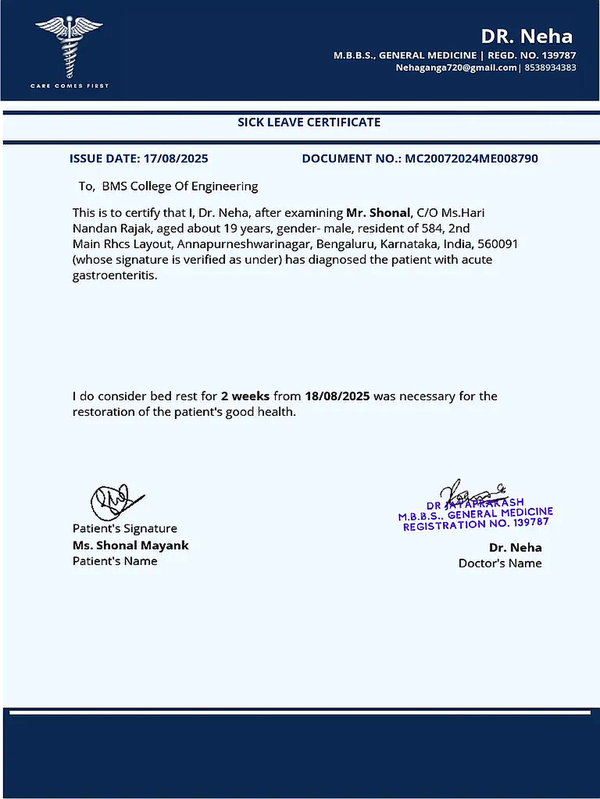

In [8]:
# Load and display the inspection image.
inspect_path = image_paths[INSPECT_INDEX]
inspect_image = load_image(inspect_path)

print(f"[{INSPECT_INDEX}] {inspect_path.name}")
print(f"Size: {inspect_image.size}  Mode: {inspect_image.mode}")
print()

# Display the image (scaled down for notebook viewing).
display_width = 600
ratio = display_width / inspect_image.width
display_size = (display_width, int(inspect_image.height * ratio))
inspect_image.resize(display_size, Image.LANCZOS)

### Extract Fields from Inspection Image

Runs `extract_fields_qa()` on the loaded image and prints each field with its
extracted value and confidence score.

**Interpreting confidence scores:**
- **> 0.9** — Very confident, likely correct
- **0.5 – 0.9** — Moderately confident, verify manually
- **< 0.5** — Low confidence, may be incorrect or hallucinated
- **0.0** — Field not found (below minimum threshold)

In [9]:
print(f"Extracting fields from: {inspect_path.name}")
print("=" * 60)

inspect_fields = extract_fields_qa(inspect_image)

print("\n=== Extracted Fields ===")
for field_name in _FIELD_QUESTIONS.keys():
    value = inspect_fields.get(field_name)
    confidence = inspect_fields.get(f"{field_name}_confidence", 0.0)
    
    # Confidence indicator.
    if confidence >= 0.9:
        indicator = "✓✓"
    elif confidence >= 0.5:
        indicator = "✓"
    elif confidence > 0:
        indicator = "?"
    else:
        indicator = "✗"
    
    print(f"{indicator} {field_name:20s}: {value or '(not found)':30s}  [conf: {confidence:.2%}]")

Extracting fields from: sicknote_1.png
Loading LayoutLM model (impira/layoutlm-document-qa) — first call only, ~30–60 sec ...


Loading weights: 100%|██████████| 205/205 [00:00<00:00, 46056.69it/s]


LayoutLM model ready.

=== Extracted Fields ===
✓✓ patient_name        : Ms. Shonal Mayank               [conf: 99.31%]
✓✓ doctor_name         : Dr. Neha,                       [conf: 99.60%]
? clinic_name         : ENERAL MEDICINE                 [conf: 36.83%]
✓✓ certificate_id      : MC20072024ME008790              [conf: 99.86%]
✓✓ issue_date          : 17/08/2025                      [conf: 100.00%]


## Step 5 — Batch Processing

Runs the full pipeline on **every image in `IMAGE_FOLDER`** and collects the
results into a list of dicts (which the next cell turns into a DataFrame).

For each file:
1. Load image — `pdf_page_to_image()` for `.pdf`, otherwise `Image.open()`.
2. `extract_fields_qa()` → structured dictionary with confidence scores.
3. Append a merged row: `{file, **fields}`.

The `except Exception` around each iteration is intentional — the batch loop
must keep going even if a single image fails, and the failure row records the
error string so you can spot it in the DataFrame.

In [10]:
results = []

for i, path in enumerate(image_paths):
    print(f"[{i+1}/{len(image_paths)}] Processing {path.name} ...", end=" ", flush=True)
    try:
        img = load_image(path)
        fields = extract_fields_qa(img)
        
        results.append({
            "file": path.name,
            "subfolder": path.parent.name,
            **fields,
        })
        
        # Show quick summary.
        patient = fields.get("patient_name") or "—"
        date = fields.get("issue_date") or "—"
        print(f"OK  (patient: {patient}, date: {date})")
        
    except Exception as exc:  # noqa: BLE001
        print(f"FAILED — {exc}")
        results.append({"file": path.name, "subfolder": path.parent.name, "error": str(exc)})

print(f"\nDone. {len(results)} image(s) processed.")

[1/23] Processing Sick_Note_1.jpg ...   [Image — light preprocessing]
OK  (patient: Beileigh Byle, date: May 19, 2021)
[2/23] Processing Sick_note_2.jpg ...   [Image — light preprocessing]
OK  (patient: T'Erika Harley, date: January 29, 2022)
[3/23] Processing Sick_note_8.pdf ...   [Native PDF — 150 DPI, no preprocessing]
OK  (patient: Gastroenterology Specialist, date: —)
[4/23] Processing sick_note_10.jpg ...   [Image — light preprocessing]
OK  (patient: JOHANNIS, TORRES, date: 05/27/2017)
[5/23] Processing sick_note_12.pdf ...   [Native PDF — 150 DPI, no preprocessing]
OK  (patient: Rafael Ilyayev,, date: Monday June 28th, 2021)
[6/23] Processing sick_note_13.jpg ...   [Image — light preprocessing]
OK  (patient: Dr. Waters, date: 11/13/2017)
[7/23] Processing sick_note_14.pdf ...   [Native PDF — 150 DPI, no preprocessing]
OK  (patient: DR. RILEY SNIPES, date: September 17, 2025)
[8/23] Processing sick_note_15.jpg ...   [Image — light preprocessing]
OK  (patient: Nelly Darwin, date: 

### Results as a Pandas DataFrame

Builds a `pandas.DataFrame` with a human-friendly column order:

- **Priority columns first** — `file`, `subfolder`, then the main extracted fields.
- **Confidence columns** — grouped after each field.
- **Error column** — at the end (only present for failed rows).

The DataFrame provides a quick overview of extraction quality across all images.

In [11]:
import pandas as pd
import json

# Print raw JSON for full inspection.
print("=== Raw Results (JSON) ===")
print(json.dumps(results, indent=2, default=str))

# Build DataFrame.
df = pd.DataFrame(results)

# Define column order.
priority_cols = [
    "file", "subfolder",
    "patient_name", "patient_name_confidence",
    "doctor_name", "doctor_name_confidence",
    "clinic_name", "clinic_name_confidence",
    "certificate_id", "certificate_id_confidence",
    "issue_date", "issue_date_confidence",
]
ordered_cols = [c for c in priority_cols if c in df.columns] + \
               [c for c in df.columns if c not in priority_cols]

# Display settings.
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.max_columns", 20)

print("\n=== Results DataFrame ===")
df[ordered_cols]

=== Raw Results (JSON) ===
[
  {
    "file": "Sick_Note_1.jpg",
    "subfolder": "Test data",
    "patient_name": "Beileigh Byle",
    "patient_name_confidence": 0.9993,
    "doctor_name": "Lovette Dobson",
    "doctor_name_confidence": 0.9999,
    "clinic_name": "Lankeanu Medical Center",
    "clinic_name_confidence": 0.9999,
    "certificate_id": "(484) 476-2000",
    "certificate_id_confidence": 0.3447,
    "issue_date": "May 19, 2021",
    "issue_date_confidence": 0.9994
  },
  {
    "file": "Sick_note_2.jpg",
    "subfolder": "Test data",
    "patient_name": "T'Erika Harley",
    "patient_name_confidence": 0.9998,
    "doctor_name": "Jennifer A. Greene",
    "doctor_name_confidence": 0.9994,
    "clinic_name": "N LEXINGTON MEDICAL CENTER",
    "clinic_name_confidence": 0.9976,
    "certificate_id": "TemplateLAB",
    "certificate_id_confidence": 0.9967,
    "issue_date": "January 29, 2022",
    "issue_date_confidence": 0.9999
  },
  {
    "file": "Sick_note_8.pdf",
    "subfolder"

,file,subfolder,patient_name,patient_name_confidence,doctor_name,doctor_name_confidence,clinic_name,clinic_name_confidence,certificate_id,certificate_id_confidence,issue_date,issue_date_confidence
0,Sick_Note_1.jpg,Test data,Beileigh Byle,0.9993,Lovette Dobson,0.9999,Lankeanu Medical Center,0.9999,(484) 476-2000,0.3447,"May 19, 2021",0.9994
1,Sick_note_2.jpg,Test data,T'Erika Harley,0.9998,Jennifer A. Greene,0.9994,N LEXINGTON MEDICAL CENTER,0.9976,TemplateLAB,0.9967,"January 29, 2022",0.9999
2,Sick_note_8.pdf,Test data,Gastroenterology Specialist,1.0000,Gastroenterology Specialist,0.9999,contact@stheliosmed.org,0.7497,(325) 880-4213,0.9584,NaN,0.0000
3,sick_note_10.jpg,Test data,"JOHANNIS, TORRES",0.9999,"JOHANNIS, TORRES",0.9998,FLORIDA HOSPITAL,0.9999,INSTRUCTIONS,0.9973,05/27/2017,0.9999
4,sick_note_12.pdf,Test data,"Rafael Ilyayev,",0.9997,"Rafael Ilyayev,",0.9998,Refua Shlema Medical PC,0.9998,NaN,0.0000,"Monday June 28th, 2021",0.9996
5,sick_note_13.jpg,Test data,Dr. Waters,0.9997,Dr. Waters,0.9999,Dr. Waters,0.7077,Acid Reflex,0.8229,11/13/2017,0.9998
6,sick_note_14.pdf,Test data,DR. RILEY SNIPES,0.9999,DR. RILEY SNIPES,0.9999,Central Hospital,1.0000,"September 17, 2025",0.8775,"September 17, 2025",0.9999
7,sick_note_15.jpg,Test data,Nelly Darwin,1.0000,Dr. Riley Snipes,0.9946,Central Hospital,1.0000,"September 17, 2025",0.9536,"September 17, 2025",1.0000
8,sick_note_17.pdf,Test data,"Emily Johnson,",0.9999,"Dr. Sarah Mitchell,",0.9730,Northside Family Medical Clinic,0.9998,(555) 123-4567,0.9993,"August 3, 2026",0.9999
9,sick_note_18.pdf,Test data,"Emily Thompson,",0.9998,"Dr. Jessica Monroe,",0.9953,jmonroe@crestlinedental.com,0.9680,jmonroe@crestlinedental.com,0.9745,25 September 2025,1.0000


## Step 6 — Summary Statistics

Quick overview of extraction success rates and average confidence scores
across all processed images.

In [12]:
print("=== Extraction Summary ===")
print(f"Total images processed: {len(results)}")
print()

# Count successful extractions per field.
for field_name in _FIELD_QUESTIONS.keys():
    # Count non-None values.
    extracted = sum(1 for r in results if r.get(field_name) is not None)
    pct = (extracted / len(results)) * 100 if results else 0
    
    # Average confidence for extracted values.
    conf_key = f"{field_name}_confidence"
    confidences = [r.get(conf_key, 0) for r in results if r.get(field_name) is not None]
    avg_conf = sum(confidences) / len(confidences) if confidences else 0
    
    print(f"{field_name:20s}: {extracted:2d}/{len(results)} extracted ({pct:5.1f}%)  avg confidence: {avg_conf:.2%}")

# Count errors.
errors = sum(1 for r in results if "error" in r)
if errors:
    print(f"\nErrors: {errors} image(s) failed to process")

=== Extraction Summary ===
Total images processed: 23

patient_name        : 23/23 extracted (100.0%)  avg confidence: 99.89%
doctor_name         : 23/23 extracted (100.0%)  avg confidence: 99.74%
clinic_name         : 22/23 extracted ( 95.7%)  avg confidence: 90.58%
certificate_id      : 22/23 extracted ( 95.7%)  avg confidence: 92.76%
issue_date          : 22/23 extracted ( 95.7%)  avg confidence: 99.22%


## Appendix — Custom Question Testing

Use this cell to test custom questions on the inspection image. Helpful for
debugging extraction or trying alternative phrasings.

In [13]:
# Test custom questions on the inspection image.
custom_questions = [
    "What is the patient's name?",
    "What is the diagnosis?",
    "What is the sick leave period?",
    "From when to when is the sick leave?",
]

print(f"Testing custom questions on: {inspect_path.name}")
print("=" * 60)

for question in custom_questions:
    result = _ask_question(inspect_image, question)
    answer = result["answer"] or "(no answer)"
    score = result["score"]
    print(f"\nQ: {question}")
    print(f"A: {answer}  [confidence: {score:.2%}]")

Testing custom questions on: sicknote_1.png

Q: What is the patient's name?
A: Ms. Shonal Mayank  [confidence: 99.31%]

Q: What is the diagnosis?
A: acute gastroenteritis.  [confidence: 99.60%]

Q: What is the sick leave period?
A: 17/08/2025  [confidence: 99.75%]

Q: From when to when is the sick leave?
A: 17/08/2025  [confidence: 95.67%]
